# Week3 (Regression) 과제
## Boston Housing Data 분석
### 데이터 소개
- **CRIM**: Per capita crime rate by town.
- **ZN**: Proportion of residential land zoned for lots over 25,000 square feet.
- **INDUS**: Proportion of non-retail business acres per town.
- **CHAS**: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).
- **NOX**: Nitric oxide concentration (parts per 10 million).
- **RM**: Average number of rooms per dwelling.
- **AGE**: Proportion of owner-occupied units built prior to 1940.
- **DIS**: Weighted distances to five Boston employment centers.
- **RAD**: Index of accessibility to radial highways.
- **TAX**: Full-value property tax rate per $10,000.
- **PTRATIO**: Pupil-teacher ratio by town.
- **B**: 1000(Bk - 0.63)^2 where Bk is the proportion of Black residents by town.
- **LSTAT**: Percentage of lower status of the population.

Target Variable:
- **MEDV**: Median value of owner-occupied homes in $1000s.

In [1]:
# 코랩 환경: 구글 드라이브를 코랩에 연동
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [9]:
# housing.xls가 포함된 경로를 저장해봅시다.
PATH = '/content/drive/MyDrive/'

In [12]:
# 본인 구글 드라이브에 업로드한 housing.xls 파일의 주소를 넣어주세요!
house = pd.read_excel(PATH+'housing.xls')

# Q1: `head`, `info`, `describe`, `shape` 함수를 실행해봅시다.

과제2 참고

In [13]:
# .head()

# .info()

# .describe()

# .shape

In [19]:
# 상위 5개 행 미리보기
display(house.head())

#컬럽별 데이터 타입,결츱치 개수, 전체정보 확인
house.info()

#수치형 컬럼들의 통계요약
display(house.describe())

# 튜플로 반환 (행,열)
display(house.shape)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


(506, 14)

# Q2: 각 변수의 결측치 (NaN 또는 Null)의 개수를 구해봅시다.

과제2 참고

In [20]:
# NaN의 개수 구하기
house.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


# Q3: 각 변수별로 히스토그램을 그리고, Scatterplot Matrix를 그려봅시다

과제2 참고

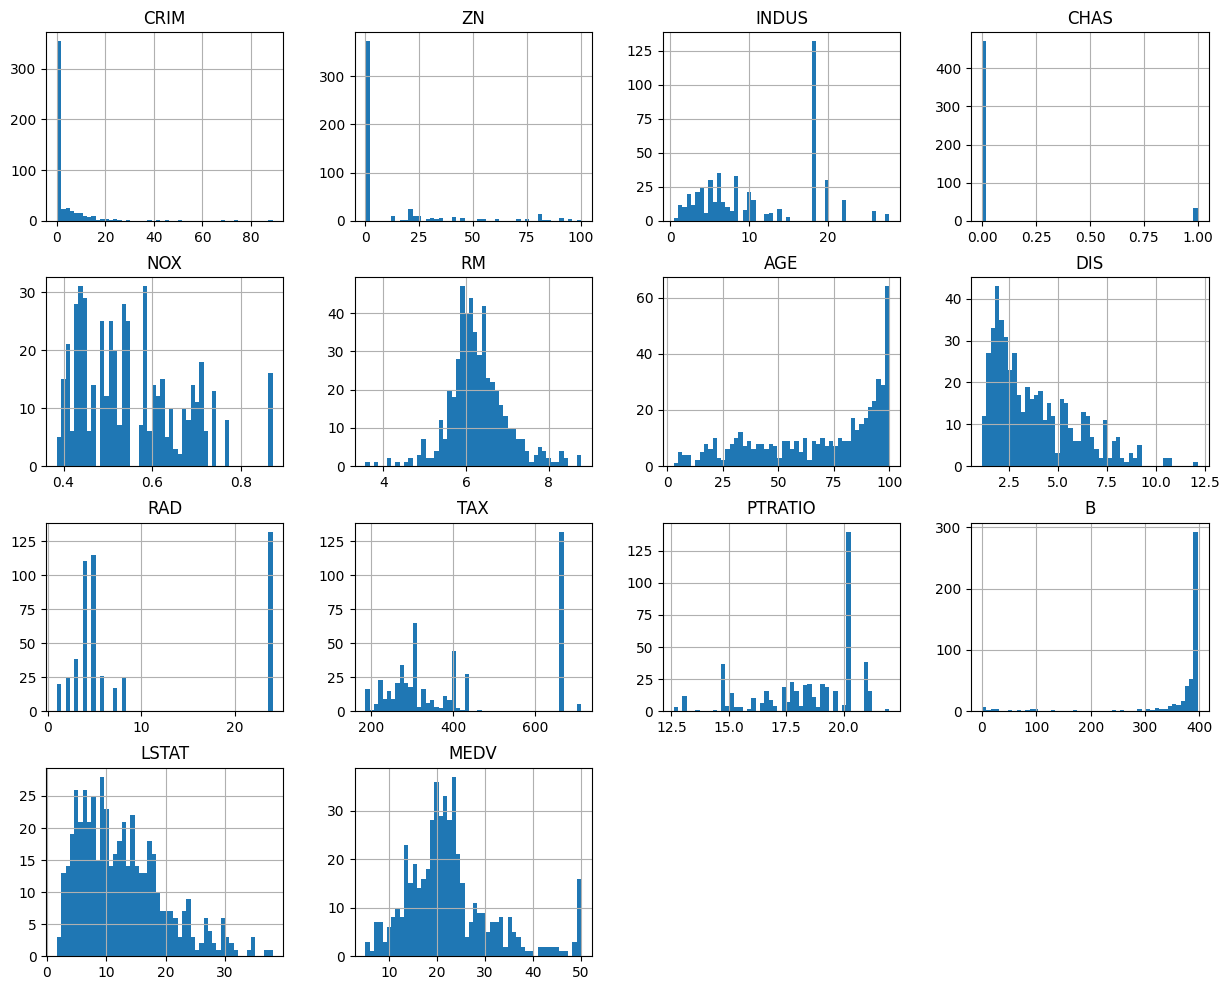

In [28]:
# Histogram
house.hist(figsize=(15,12), bins=50)
plt.tight_layout
plt.show()


In [ ]:
# Scatterplot Matrix




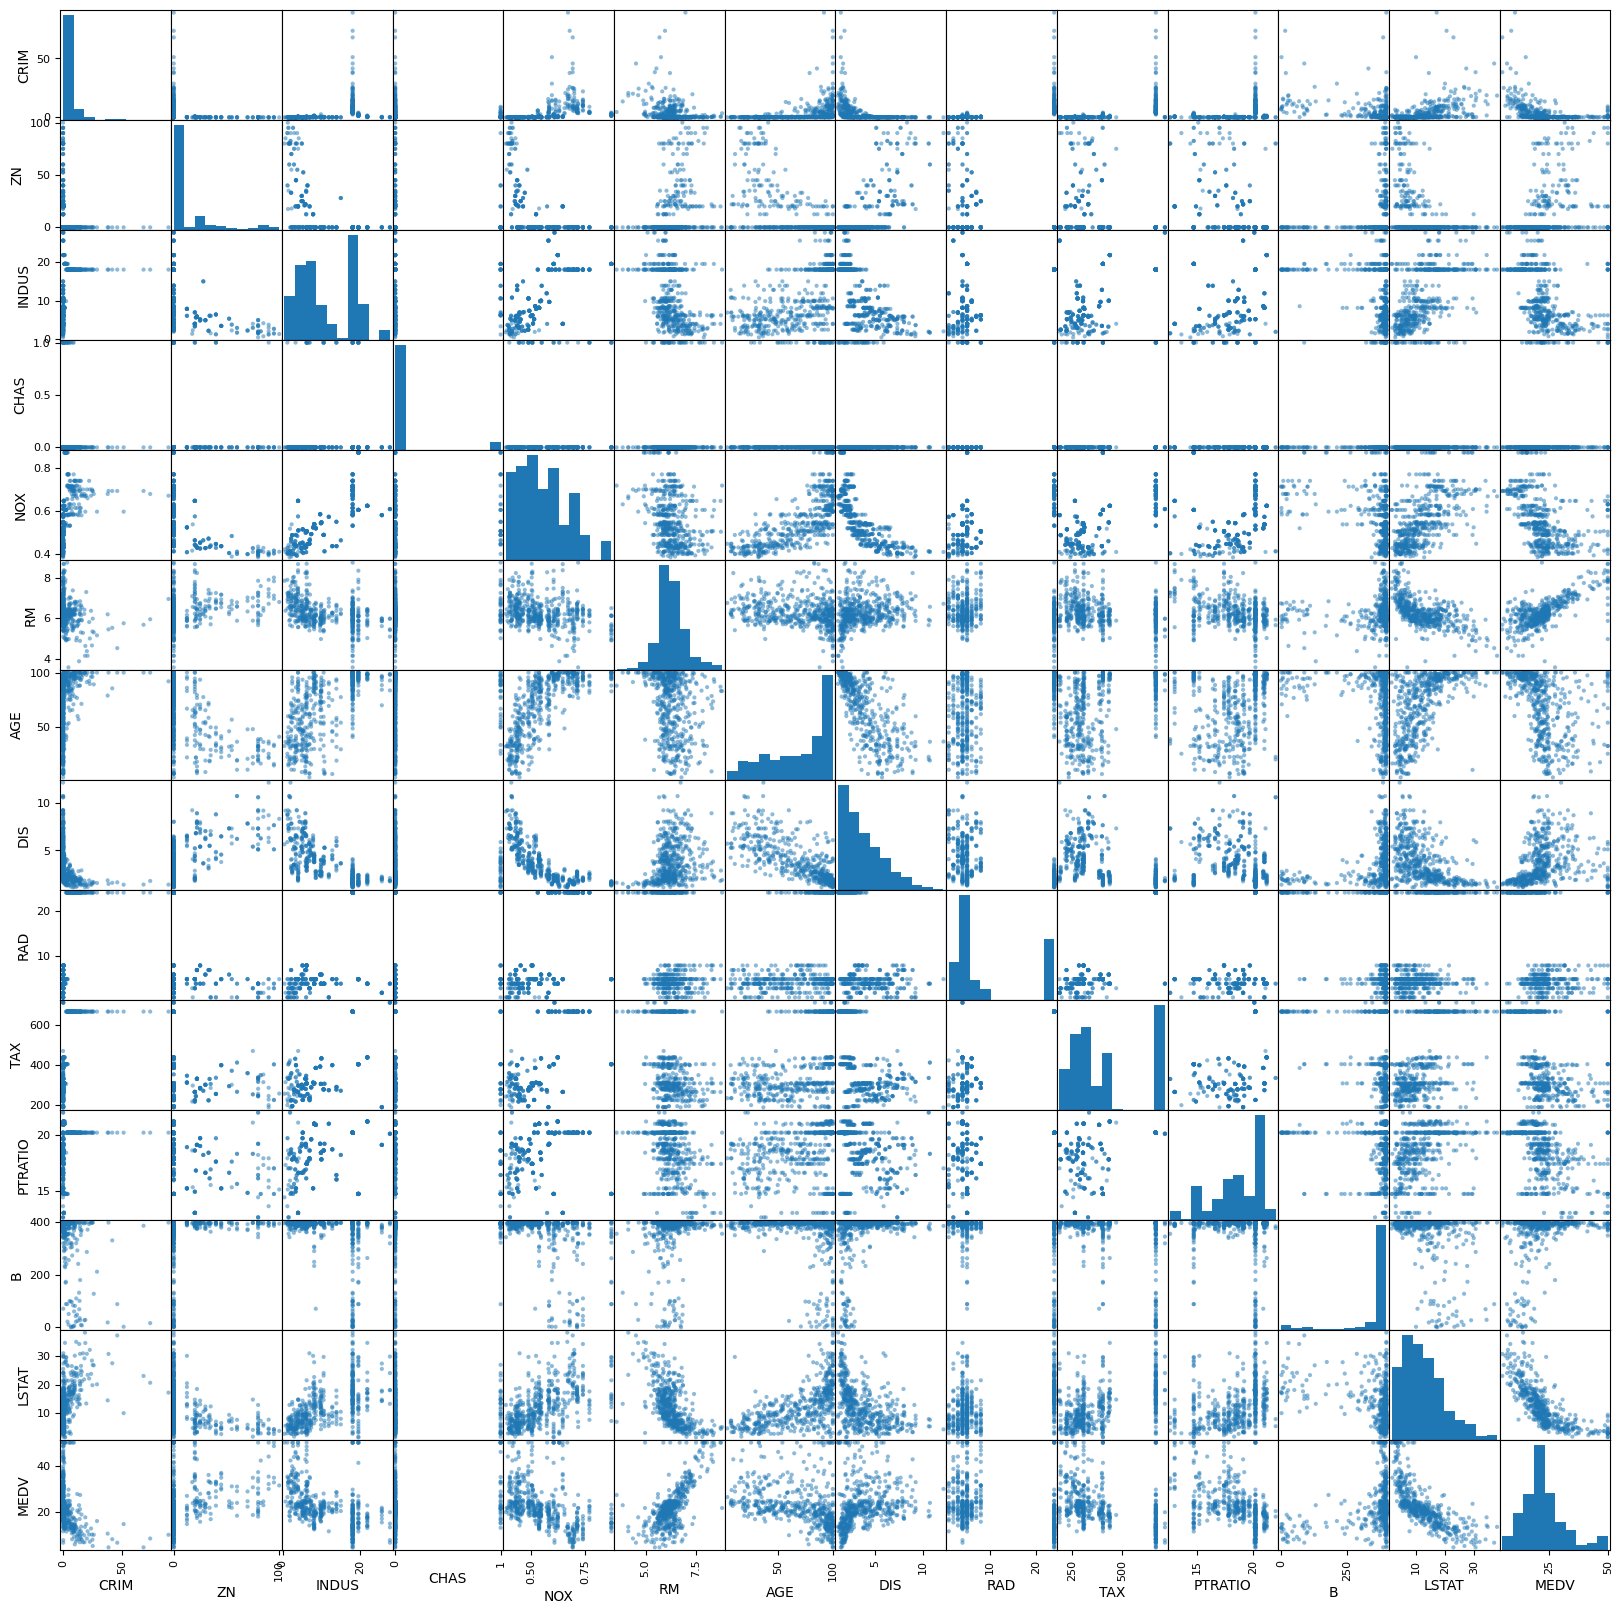

In [29]:
#Pandas로
from pandas.plotting import scatter_matrix
scatter_matrix(house, figsize=(20,20),diagonal='hist')
plt.show()

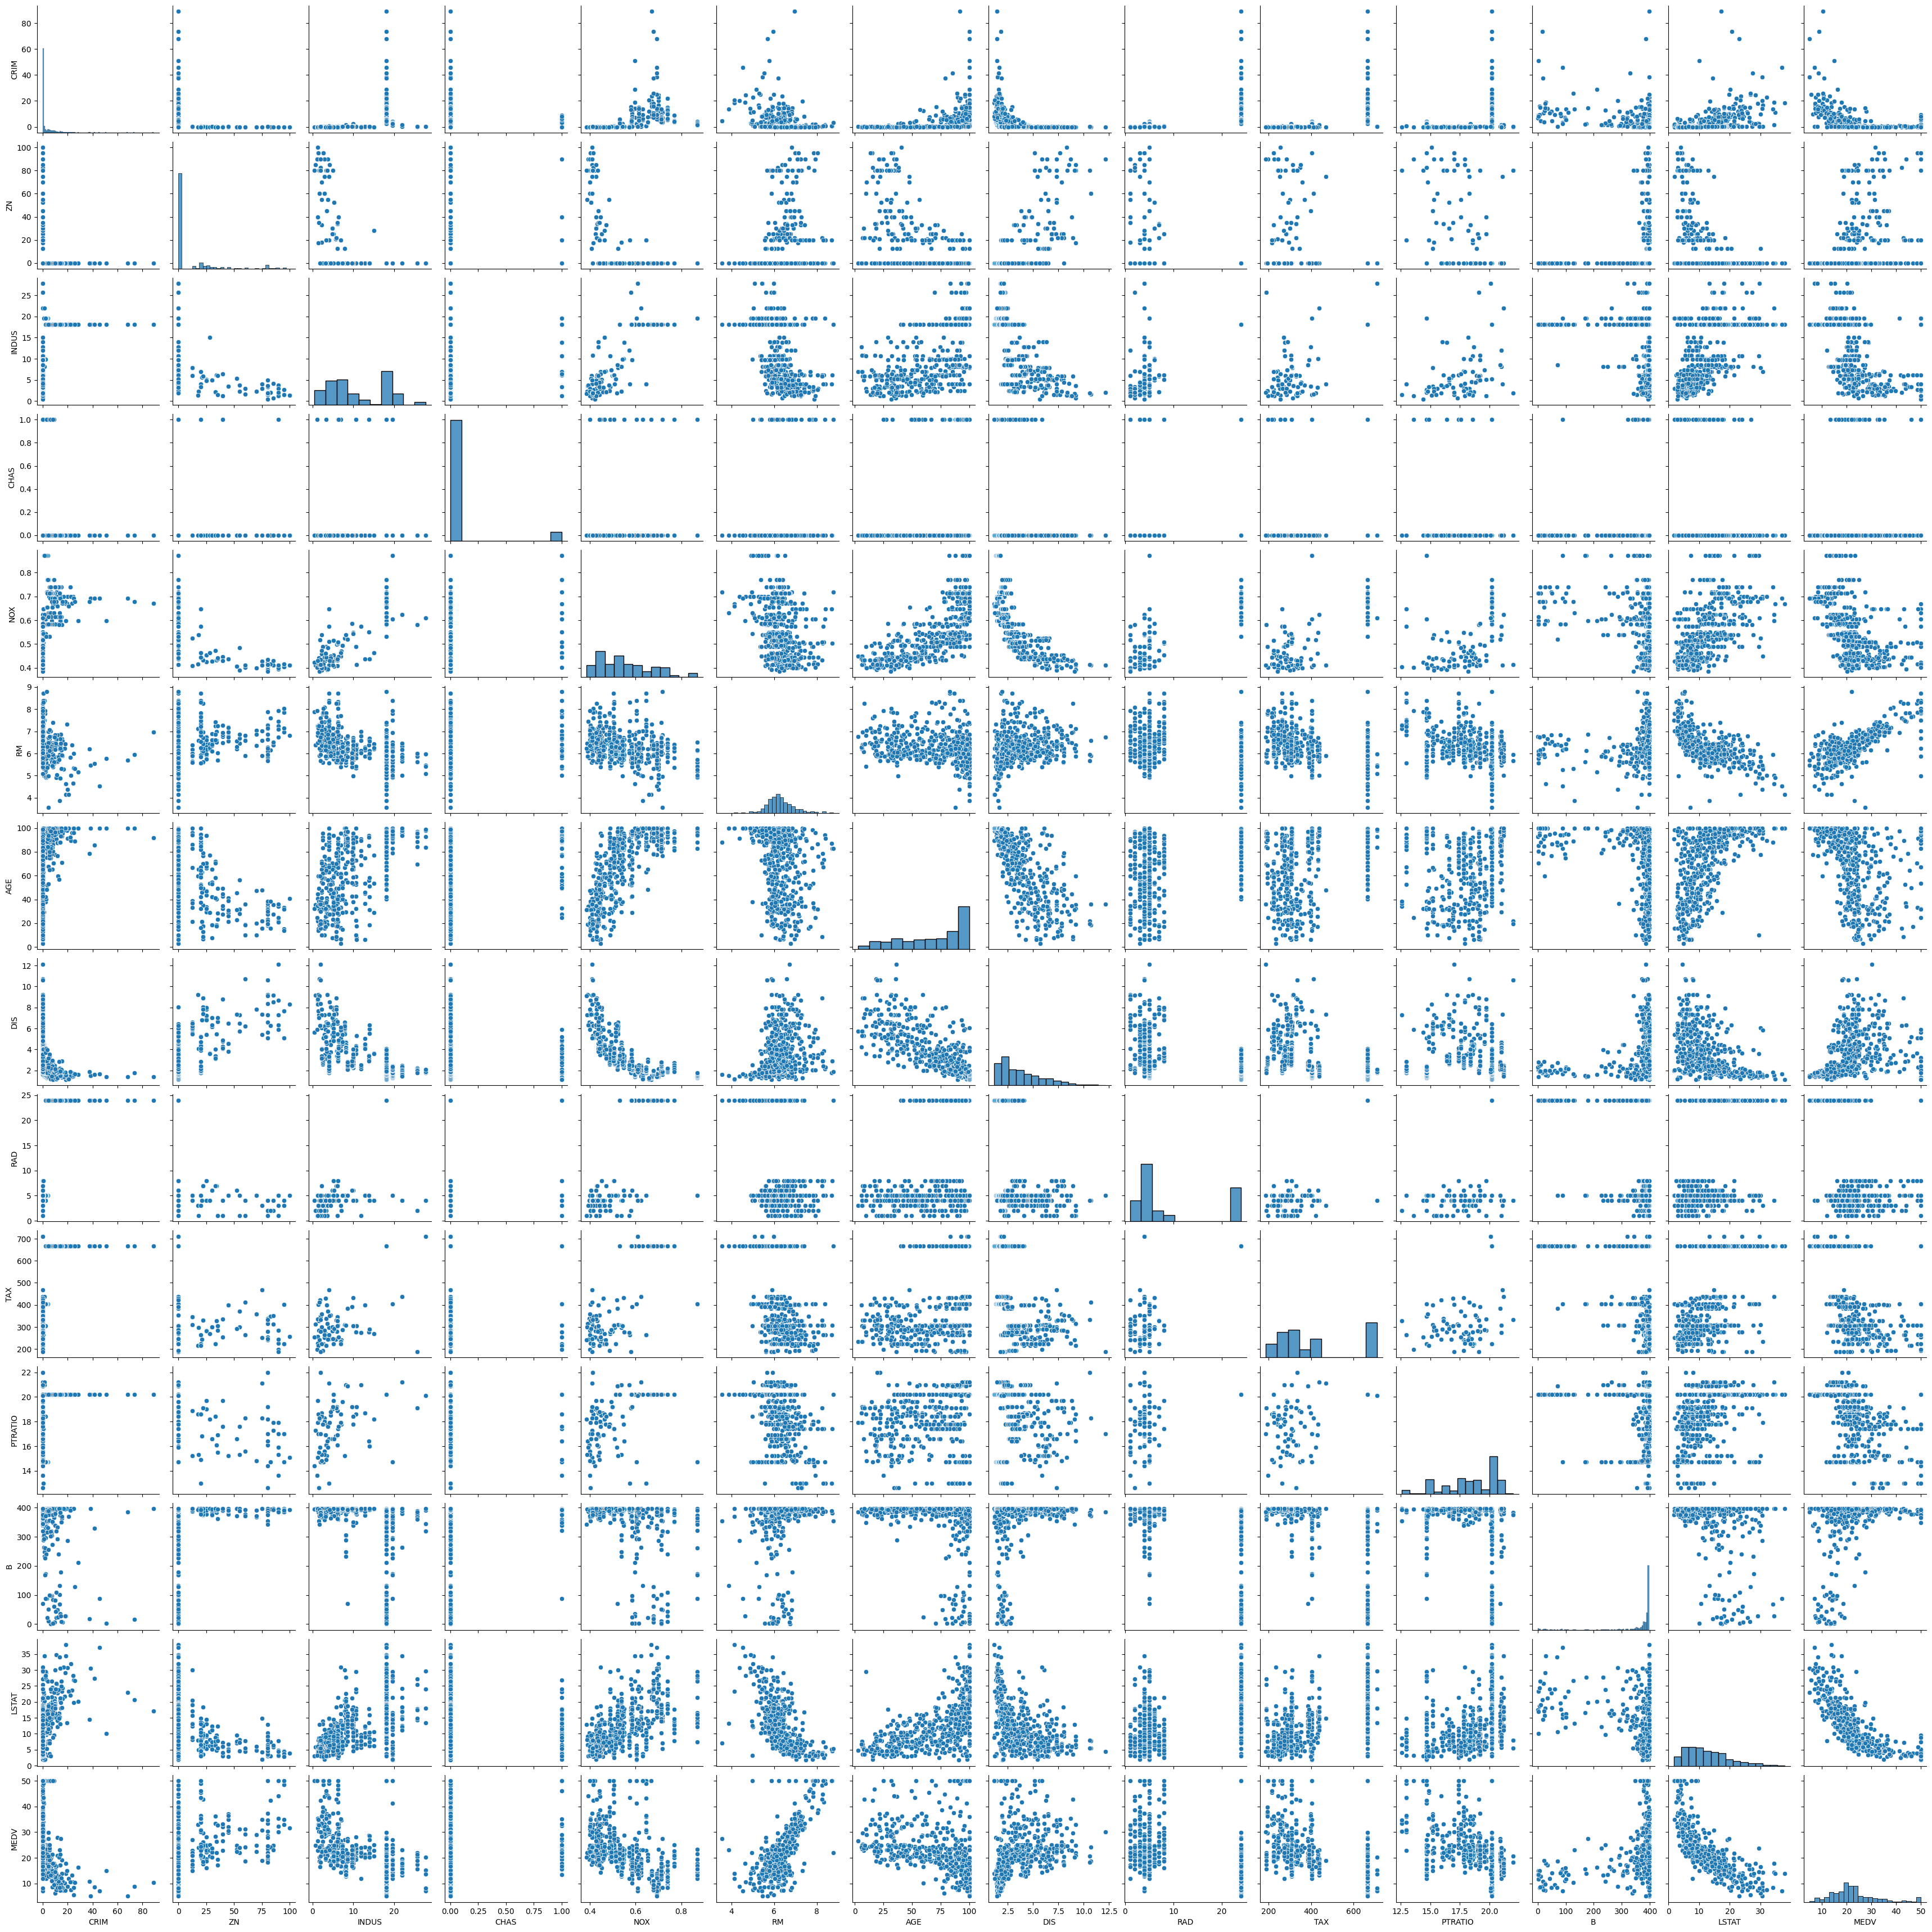

In [30]:
#Seaborn
sns.pairplot(house)
plt.show()

## Q3-1. 다중공선성(multicolinearity)을 확인하기 위해 VIF를 추가로 확인해봅시다.

In [31]:
# 그대로 실행하기 !!
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['VIF Factor'] = [variance_inflation_factor(house.values, i) for i in range(house.shape[1])]
vif['features'] = house.columns
vif

,VIF Factor,features
0,2.131404,CRIM
1,2.910004,ZN
2,14.485874,INDUS
3,1.176266,CHAS
4,74.004269,NOX
5,136.101743,RM
6,21.398863,AGE
7,15.430455,DIS
8,15.369980,RAD
9,61.939713,TAX


## Q3-2.
VIF가 높은 변수가 하나씩 줄어들면 다른 변수들의 VIF에도 영향을 미치기 때문에 변수들을 한 번에 다 제거하기보다는 하나씩 제거하면서 확인해 나아가는 것이 바람직합니다! 여러 차례 VIF를 확인해보면서 변수를 제거해보세요!

In [33]:
#RM제거

vif = pd.DataFrame()
x_data = house.drop( 'RM' ,axis=1) # VIF 높은 변수 기입
vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
vif["features"] = x_data.columns
vif

,VIF Factor,features
0,2.110287,CRIM
1,2.889159,ZN
2,14.202832,INDUS
3,1.174535,CHAS
4,62.073615,NOX
5,20.752654,AGE
6,14.258330,DIS
7,15.134503,RAD
8,61.603579,TAX
9,69.068505,PTRATIO


In [34]:
#추가적으로 PTRATIO 제거

vif = pd.DataFrame()
x_data = house.drop([ 'RM', 'PTRATIO'], axis=1)
vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
vif["features"] = x_data.columns
vif

,VIF Factor,features
0,2.104099,CRIM
1,2.558330,ZN
2,14.147928,INDUS
3,1.162582,CHAS
4,59.247225,NOX
5,20.427509,AGE
6,9.639018,DIS
7,15.130157,RAD
8,58.759509,TAX
9,19.222365,B


** *이탤릭체 텍스트*house 데이터셋에 변수 제거를 적용하지 않고 우선 진행하세요! 추후에 MSE 비교를 통해 변수 제거를 확실히 해봅시다.**

# Q4: 데이터를 `X_train`, `X_test`, `y_train`, `y_test` 로 split해 봅시다

split 비율은 자유롭게 정해보시기 바랍니다.

In [41]:
# train_test_split

from sklearn.model_selection import train_test_split

X = house.drop('MEDV', axis=1) #독립변수들
y = house['MEDV'] #종속변수

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 데이터 분할 확인
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((404, 13), (102, 13), (404,), (102,))

# Q5: `StandardScaler`로 표준화를 해봅시다

CRIM, ZN, INDUS, NOX, RM, AGE, DIS, TAX, PTRATIO, B, LSTAT 변수들만 `StandardScaler`을 해봅시다. (이들 중 다중공선성으로 인해 제거한 변수들이 있다면 제외하고 진행해주세요.)

`X_train`은 `fit_transform`, `X_test`는 `transform`을 이용하는 것에 유의합시다!

In [42]:
# StandardScaler

from sklearn.preprocessing import StandardScaler

# 표준화할 변수 목록 (RM, PTRATIO는 이미 제거했으니 제외)
cols_to_scale = ['CRIM', 'ZN', 'INDUS', 'NOX', 'AGE', 'DIS', 'TAX', 'B', 'LSTAT']

scaler = StandardScaler()

# train은 fit_transform (평균/표준편차 학습 + 변환)
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# test는 transform만 (train에서 학습한 기준으로 변환만)
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# 표준화 결과 확인 (평균 0, 표준편차 1 근처인지)
X_train[cols_to_scale].describe()


,CRIM,ZN,INDUS,NOX,AGE,DIS,TAX,B,LSTAT
count,4.040000e+02,404.000000,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02
mean,-2.638154e-17,0.000000,-4.177077e-17,-5.111423e-16,-4.858600e-16,5.248827e-17,-1.516938e-16,-4.946538e-16,-1.791746e-16
std,1.001240e+00,1.001240,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00
min,-4.061414e-01,-0.500320,-1.487791e+00,-1.458711e+00,-2.348206e+00,-1.258391e+00,-1.307684e+00,-3.892249e+00,-1.510559e+00
25%,-3.979761e-01,-0.500320,-8.502733e-01,-8.887828e-01,-8.228264e-01,-8.081981e-01,-7.533563e-01,2.098797e-01,-8.005057e-01
50%,-3.776748e-01,-0.500320,-3.521669e-01,-1.572334e-01,3.270201e-01,-2.971196e-01,-4.460660e-01,3.830012e-01,-2.157763e-01
75%,-4.582119e-02,0.364589,1.033237e+00,6.338607e-01,8.974727e-01,7.481981e-01,1.578434e+00,4.316600e-01,5.513070e-01
max,9.630689e+00,3.824227,2.433163e+00,2.675394e+00,1.124581e+00,3.907900e+00,1.849573e+00,4.441800e-01,3.592534e+00


# Q6: 5-fold Cross-Validation으로 `LinearRegression`을 적합해봅시다.

각 fold마다 적합 후 MSE, MAE, RMSE, $R^2$를 구하고, coefficient과 intercept를 `print` 해보세요.

In [60]:
# KFold, cross_val_score, cross_validation 이용

from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

#for문 시작 전에 빈 리스트 준비
mse_list, mae_list, rmse_list, r2_list = [], [], [], []

fold_num = 1
for train_idx, val_idx in kf.split(X_train):
    # 이번 fold의 train/validation 데이터 나누기
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # 모델 학습
    model = LinearRegression()
    model.fit(X_tr, y_tr)

    # 예측
    y_pred = model.predict(X_val)

    # 지표 계산
    mse = mean_squared_error(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, y_pred)

    # 계산한 값들 리스트에 저장
    mse_list.append(mse)
    mae_list.append(mae)
    rmse_list.append(rmse)
    r2_list.append(r2)

    print(f"--- Fold {fold_num} ---")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")
    print(f"Coefficients: {model.coef_}")
    print(f"Intercept: {model.intercept_}")
    print()

    fold_num += 1


--- Fold 1 ---
MSE: 23.2864
MAE: 3.2108
RMSE: 4.8256
R2: 0.6725
Coefficients: [-0.94812889  0.75860569  0.30089583  3.00762597 -2.22748976  4.9577264
 -0.0701652  -3.21933289  0.22020054 -1.4566606  -0.93513235  1.15725598
 -3.28121084]
Intercept: 6.32235765831112

--- Fold 2 ---
MSE: 23.5646
MAE: 3.4965
RMSE: 4.8543
R2: 0.7601
Coefficients: [-1.05807326  0.74220183  0.10490298  3.09299413 -2.01430949  3.95152739
 -0.17481654 -3.32611962  0.24295321 -1.74209102 -0.79812171  1.09336037
 -3.97212925]
Intercept: 9.764169217855079

--- Fold 3 ---
MSE: 36.4745
MAE: 3.7736
RMSE: 6.0394
R2: 0.5895
Coefficients: [-0.83960069  0.68397371  0.56370453  0.62831766 -1.64117107  4.93113899
 -0.31189726 -2.65099913  0.22502761 -2.05077    -0.97957836  1.23827918
 -2.99696129]
Intercept: 7.3781054016382495

--- Fold 4 ---
MSE: 25.7558
MAE: 3.9217
RMSE: 5.0750
R2: 0.7592
Coefficients: [-1.0337213   0.32691448 -0.03308526  4.61419375 -1.99624146  4.12097273
 -0.29251259 -2.88703739  0.28517372 -1.427918

### Q6-1: 다중공선성이 높았던 변수를 제거한 후 다시 train_test_split, scaler, 5-fold CV 과정으로 `LinearRegression`을 적합한 후 Q6에서 구한 평균 MSE(or MAE, RMSE, $R^2$)와 비교해보세요.

In [45]:
# 다중공선성을 불러일으키는 변수 제거
house_new = house.drop(['RM', 'PTRATIO'], axis=1) # VIF 높은 변수들 기입

In [62]:
# Train/Test Split
X_new = house_new.drop('MEDV', axis=1)
y_new = house_new['MEDV']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

# 데이터 분할 확인
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((404, 13), (102, 13), (404,), (102,))

In [63]:
# StandardScaler (RM, PTRATIO 이미 빠졌으니 나머지 수치형 변수 목록에서도 제외)
cols_to_scale_new = ['CRIM', 'ZN', 'INDUS', 'NOX', 'AGE', 'DIS', 'TAX', 'B', 'LSTAT']

scaler_new = StandardScaler()
X_train_new[cols_to_scale_new] = scaler_new.fit_transform(X_train_new[cols_to_scale_new])
X_test_new[cols_to_scale_new] = scaler_new.transform(X_test_new[cols_to_scale_new])

# 표준화 결과 확인 (평균 0, 표준편차 1 근처인지)
X_train[cols_to_scale].describe()

,CRIM,ZN,INDUS,NOX,AGE,DIS,TAX,B,LSTAT
count,4.040000e+02,404.000000,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02
mean,-2.638154e-17,0.000000,-4.177077e-17,-5.111423e-16,-4.858600e-16,5.248827e-17,-1.516938e-16,-4.946538e-16,-1.791746e-16
std,1.001240e+00,1.001240,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00
min,-4.061414e-01,-0.500320,-1.487791e+00,-1.458711e+00,-2.348206e+00,-1.258391e+00,-1.307684e+00,-3.892249e+00,-1.510559e+00
25%,-3.979761e-01,-0.500320,-8.502733e-01,-8.887828e-01,-8.228264e-01,-8.081981e-01,-7.533563e-01,2.098797e-01,-8.005057e-01
50%,-3.776748e-01,-0.500320,-3.521669e-01,-1.572334e-01,3.270201e-01,-2.971196e-01,-4.460660e-01,3.830012e-01,-2.157763e-01
75%,-4.582119e-02,0.364589,1.033237e+00,6.338607e-01,8.974727e-01,7.481981e-01,1.578434e+00,4.316600e-01,5.513070e-01
max,9.630689e+00,3.824227,2.433163e+00,2.675394e+00,1.124581e+00,3.907900e+00,1.849573e+00,4.441800e-01,3.592534e+00


In [64]:
# 5-Fold CV
kf_new = KFold(n_splits=5, shuffle=True, random_state=42)

#for문 시작 전에 빈 리스트 준비
mse_list_new, mae_list_new, rmse_list_new, r2_list_new = [], [], [], []

fold_num = 1
for train_idx, val_idx in kf_new.split(X_train_new):
    X_tr, X_val = X_train_new.iloc[train_idx], X_train_new.iloc[val_idx]
    y_tr, y_val = y_train_new.iloc[train_idx], y_train_new.iloc[val_idx]

    model_new = LinearRegression()
    model_new.fit(X_tr, y_tr)

    y_pred = model_new.predict(X_val)

    mse = mean_squared_error(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, y_pred)

    #계산한 값들 리스트에 저장
    mse_list_new.append(mse)
    mae_list_new.append(mae)
    rmse_list_new.append(rmse)
    r2_list_new.append(r2)

    print(f"--- Fold {fold_num} ---")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")
    print(f"Coefficients: {model_new.coef_}")
    print(f"Intercept: {model_new.intercept_}")
    print()

    fold_num += 1

--- Fold 1 ---
MSE: 24.0377
MAE: 3.6672
RMSE: 4.9028
R2: 0.6619
Coefficients: [-1.05300997  2.40993808 -0.93402836  3.8344713  -1.07204488  0.82946233
 -4.39182559  0.26069405 -2.71948179  0.74140904 -6.19946689]
Intercept: 20.065869889064455

--- Fold 2 ---
MSE: 40.6591
MAE: 4.2550
RMSE: 6.3765
R2: 0.5860
Coefficients: [-0.98796382  2.14663815 -0.76954652  4.28591323 -1.40469166  0.49701947
 -4.10921413  0.2436008  -2.52845698  0.73775993 -6.00661516]
Intercept: 20.001301495921744

--- Fold 3 ---
MSE: 37.7632
MAE: 4.4882
RMSE: 6.1452
R2: 0.5749
Coefficients: [-0.95928034  2.33488566 -0.38586731  2.37742012 -0.72954675  0.22274489
 -4.12148835  0.28485193 -3.3578025   0.6645402  -6.09768532]
Intercept: 19.946550234285986

--- Fold 4 ---
MSE: 37.1777
MAE: 4.5664
RMSE: 6.0974
R2: 0.6524
Coefficients: [-1.07653494  1.72277542 -0.82232248  5.18483911 -1.12096225  0.23239723
 -3.82821344  0.28424    -2.41451607  0.76902139 -6.16334945]
Intercept: 19.75450183386442

--- Fold 5 ---
MSE: 20.73

In [66]:
comparison = pd.DataFrame({
    '지표': ['MSE', 'MAE', 'RMSE', 'R2'],
    '원본 (13개 변수)': [np.mean(mse_list), np.mean(mae_list), np.mean(rmse_list), np.mean(r2_list)],
    'RM/PTRATIO 제거 (11개 변수)': [np.mean(mse_list_new), np.mean(mae_list_new), np.mean(rmse_list_new), np.mean(r2_list_new)]
})
comparison

,지표,원본 (13개 변수),RM/PTRATIO 제거 (11개 변수)
0,MSE,24.318384,32.074264
1,MAE,3.428409,4.100386
2,RMSE,4.866280,5.615044
3,R2,0.718478,0.632477


RM, PTRATIO 제거 시 다중공선성은 개선되지만 예측 성능(R², MSE 등)이 유의미하게 저하됨. 이는 RM이 MEDV 예측에 중요한 정보를 담고 있기 때문으로 보이며, 본 분석에서는 예측 성능을 우선하여 원본(13개 변수) 모델을 채택하는 것이 타당함.

# Q7(Optional): `GridSearchCV`를 이용하여 `Lasso`를 적합해봅시다.

찾아야 하는 최적 파라미터는

- `alpha`: 0.01, 0.1, 1, 10 중에서 찾기
- `fit_intercept`: `True`, `False`에서 찾기

https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

위 링크를 참조하여 `GridSearCV`의 `scoring`을 3가지 이상 사용해보세요

In [67]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

# param_grid

param_grid = {
    'alpha': [0.01, 0.1, 1, 10],
    'fit_intercept': [True, False]
}

lasso = Lasso()

grid_mse = GridSearchCV(
    lasso, param_grid,
    scoring='neg_mean_squared_error',  # scikit-learn은 관례상 '높을수록 좋게' 만들어서 neg 붙임
    cv=5
)
grid_mse.fit(X_train, y_train)

print("Best params (MSE 기준):", grid_mse.best_params_)
print("Best score (MSE 기준):", grid_mse.best_score_)



Best params (MSE 기준): {'alpha': 0.01, 'fit_intercept': True}
Best score (MSE 기준): -23.66416686338071


In [68]:
scorings = ['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']

results = {}
for scoring in scorings:
    grid = GridSearchCV(Lasso(), param_grid, scoring=scoring, cv=5)
    grid.fit(X_train, y_train)
    results[scoring] = grid.best_params_
    print(f"[{scoring}] Best params: {grid.best_params_}, Best score: {grid.best_score_:.4f}")

[neg_mean_squared_error] Best params: {'alpha': 0.01, 'fit_intercept': True}, Best score: -23.6642
[neg_mean_absolute_error] Best params: {'alpha': 0.1, 'fit_intercept': False}, Best score: -3.3811
[r2] Best params: {'alpha': 0.01, 'fit_intercept': True}, Best score: 0.7243


MSE 기준과 R² 기준은 최적 조합이동일하다 (alpha=0.01, fit_intercept=True).

MAE는 이상치(outlier)에 덜 민감한 지표라서, MSE/R²와는 조금 다른 관점으로 "좋은 모델"을 판단

alpha=0.01은 거의 0에 가까운 작은 값이라, Lasso가 정규화(규제)를 거의 안 건 것과 유사.

즉 이 데이터에서는 Lasso의 규제가 세지 않을 때 (=거의 일반 선형회귀에 가까울 때) 성능이 제일 좋음

# Q8(Optional): `RandomizedSearchCV`를 이용하여 `Ridge`를 적합해 봅시다.

CV를 이용한 hyperparameter tuning의 또다른 방법은 `RandomizedSearchCV`입니다.
Tuning해야 하는 모수가 많을 경우 이 방법이 빠르다는 장점이 있습니다.

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html#

위 링크를 참조하거나 구글링을 하여 `Ridge`를 적합해보세요.

`n_iter`와, 파라미터 공간을 자유롭게 조정해보세요.

In [69]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

# 파라미터 공간 (자유롭게 조정 가능)
param_dist = {
    'alpha': uniform(loc=0.001, scale=100),  # 0.001 ~ 100.001 사이 연속 랜덤값
    'fit_intercept': [True, False]
}

ridge = Ridge()

random_search = RandomizedSearchCV(
    ridge,
    param_distributions=param_dist,
    n_iter=20,          # 랜덤하게 20번 조합 시도
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best score (neg MSE):", random_search.best_score_)

Best params: {'alpha': np.float64(5.642157902710026), 'fit_intercept': False}
Best score (neg MSE): -23.674195635378112


RandomizedSearchCV가 연속 구간(0.001~100)에서 랜덤 샘플링하다가 alpha≈5.64가 제일 좋다고 찾음

이 점수(-23.674, 즉 MSE≈23.674)는 Q7의 Lasso 결과(MSE≈23.664)랑 거의 비슷한 수준이야 — 아주 근소한 차이로 Lasso가 살짝 더 낫지만 실질적으로는 두 모델(Lasso vs Ridge) 성능이 비슷

fit_intercept=False는 X가 표준화(평균 0, 분산 1)돼 있어서 절편 없이도 웬만큼 잘 맞을 수 있어서 그런 걸로 보이나, random 샘플링 특성상 실행할 때마다 결과가 살짝 달라질 수 있음


Lasso(정규화 거의 없음)와 Ridge(alpha≈5.6) 둘 다 MSE 기준 23~24 근처로 성능이 비슷하고, 다만 평가지표(MSE/MAE/R²)에 따라 "최적 하이퍼파라미터"는 조금씩 달라질 수 있다는 걸 확인